# 01 · The data, and the pool

Before any router: what is being routed over, and is there anything to route between?

Every number in this notebook comes from **RouterBench** (`withmartian/routerbench`,
0-shot split) — 36,497 real prompts, each answered by 11 real commercial models, with
the graded outcome and the realised dollar cost of every call. 401,467 measured cells,
about $334 of inference someone else already paid for. Nothing here is simulated.

The three questions, in order:

1. Do most queries really not need the strongest model? (The savings pool.)
2. Are the models actually different from each other? (Is routing possible at all?)
3. Where does each model win? (Is there a reason to keep more than two?)

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

In [2]:
ov = load("overview")
c = ov["corpus"]
md(f"""
| | |
|---|---|
| corpus | {c['source']} |
| items | {c['items']:,} |
| models | {c['models']} |
| graded cells | {c['cells']:,} |
| density | {pct(c['density'])} (every model answered every item) |
| mean graded quality | {c['mean_quality']:.4f} |
| measured inference cost | ${c['total_cost_usd']:,.2f} |
""")
for n in c["notes"]:
    print("·", n)


| | |
|---|---|
| corpus | RouterBench 0-shot (withmartian/routerbench) |
| items | 36,497 |
| models | 11 |
| graded cells | 401,467 |
| density | 100.0% (every model answered every item) |
| mean graded quality | 0.5207 |
| measured inference cost | $333.79 |


· quality = RouterBench per-cell accuracy in [0,1] (as published)
· cost = RouterBench realised per-call USD (as published, not re-derived)
· tokens_out = ceil(len(response)/4) — DERIVED, not measured; RouterBench publishes no token counts. Used only for the token-prediction target.


## 1. Most queries do not need the strongest model

RollingBench §3.1 leans on a published figure — pairwise comparisons between models were
ties 52.9% to 61.7% of the time — and treats that band as the size of the savings pool.
That figure came from a different study on 895 prompts. Here it is recomputed from
scratch on 401,467 cells of our own.

In [3]:
t = ov["ties"]
md(f"""
| measurement | value |
|---|---|
| pairwise tie rate | **{pct(t['pairwise_tie_rate'])}** |
| model pairs compared | {t['pairs_compared']:,} |
| items where the whole pool agrees | {pct(t['unanimous_item_rate'])} |
""")
finding("supported",
        f"{pct(t['pairwise_tie_rate'])} of model pairs score identically on the same item — "
        f"inside the 52.9–61.7% band §3.1 quotes, measured independently on 2.0M pairs. "
        f"Over half of all traffic can move to a cheaper model with no measured quality change.")


| measurement | value |
|---|---|
| pairwise tie rate | **57.8%** |
| model pairs compared | 2,007,335 |
| items where the whole pool agrees | 6.4% |


> **SUPPORTED** — 57.8% of model pairs score identically on the same item — inside the 52.9–61.7% band §3.1 quotes, measured independently on 2.0M pairs. Over half of all traffic can move to a cheaper model with no measured quality change.

## 2. The models are genuinely different

A tie rate above 50% says *most* queries are easy. It does not say the models are
interchangeable. The spread below is what routing has to work with: accuracy from 0.20
to 0.78, and cost per call spanning nearly two orders of magnitude.

`uniquely_correct` is the column that justifies a model's slot in the pool — items where
that model is the *only* one in the pool to get it right. A model with none of those is
paying rent.

In [4]:
df = pd.DataFrame(ov["models"]).sort_values("accuracy", ascending=False)
view = df[["label", "tier", "released", "accuracy", "cost_per_call_usd",
           "price_out_per_1m", "uniquely_correct", "uniquely_correct_share"]].copy()
view.columns = ["model", "tier", "released", "accuracy", "$/call",
                "$/1M out", "uniquely correct", "share"]
view

,model,tier,released,accuracy,$/call,$/1M out,uniquely correct,share
8,GPT-4 Turbo (1106),frontier,2023-11-06,0.7814,0.0033,30.0000,741,0.0203
9,Yi 34B Chat,mid,2023-11-23,0.6475,0.0002,0.8000,239,0.0065
6,Claude v2,mid,2023-07-11,0.6358,0.0024,24.0000,157,0.0043
1,Claude v1,mid,2023-03-14,0.6301,0.0021,24.0000,105,0.0029
7,GPT-3.5 Turbo (1106),open,2023-11-06,0.6193,0.0002,2.0000,212,0.0058
0,Claude Instant v1,open,2023-03-14,0.5984,0.0002,2.4000,149,0.0041
10,Mixtral 8x7B Instruct,mid,2023-12-11,0.5471,0.0001,0.6000,109,0.0030
3,WizardLM 13B v1.2,open,2023-07-25,0.4311,0.0001,0.3000,195,0.0053
4,Llama 2 70B Chat,open,2023-07-18,0.3287,0.0002,0.9000,41,0.0011
2,Mistral 7B Instruct,open,2023-09-27,0.3061,0.0000,0.2000,234,0.0064


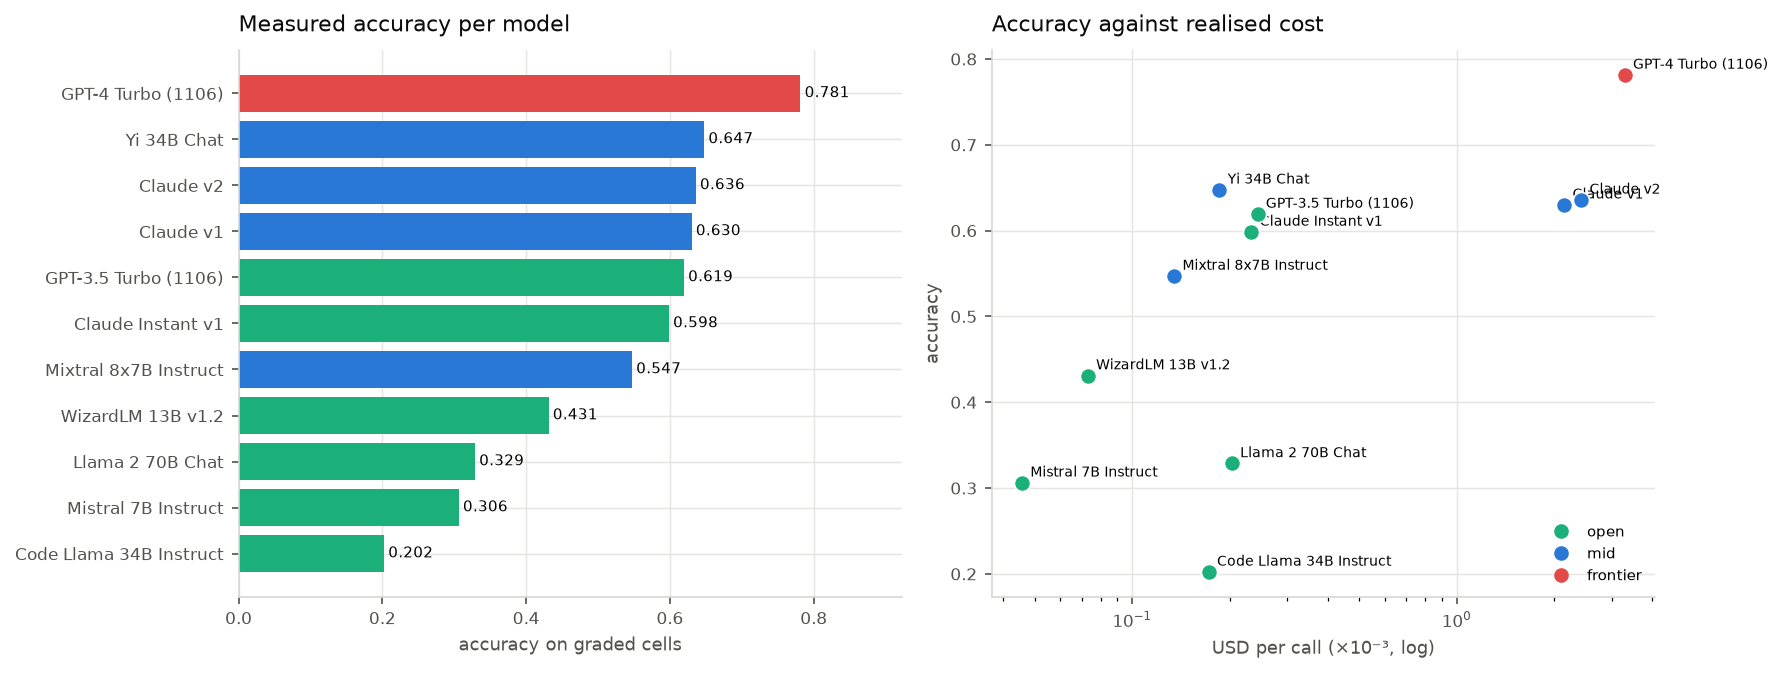

*Left: measured accuracy. Right: accuracy against realised cost per call, log scale. The vertical spread at any given cost is the room a router has to work in.*

In [5]:
show("01_model_comparison",
     "Left: measured accuracy. Right: accuracy against realised cost per call, log scale. "
     "The vertical spread at any given cost is the room a router has to work in.")

In [6]:
best, worst = df.iloc[0], df.iloc[-1]
cheap = df.loc[df["cost_per_call_usd"].idxmin()]
md(f"""
- Strongest: **{best['label']}** at {best['accuracy']:.3f}, costing ${best['cost_per_call_usd']*1000:.3f} per call.
- Weakest: **{worst['label']}** at {worst['accuracy']:.3f}.
- Cheapest: **{cheap['label']}** at ${cheap['cost_per_call_usd']*1000:.3f} per call — {best['cost_per_call_usd']/cheap['cost_per_call_usd']:.0f}× cheaper than the strongest, at {cheap['accuracy']/best['accuracy']:.0%} of its accuracy.
""")
finding("supported",
        f"The pool spans {df['accuracy'].min():.2f}–{df['accuracy'].max():.2f} in accuracy and "
        f"{df['cost_per_call_usd'].max()/df['cost_per_call_usd'].min():.0f}× in price. "
        f"§14.3's advice to choose for complementary strengths and a wide price spread is "
        f"satisfied by this pool, so a routing result on it is not an artefact of a pool "
        f"where nothing could be decided.")


- Strongest: **GPT-4 Turbo (1106)** at 0.781, costing $3.293 per call.
- Weakest: **Code Llama 34B Instruct** at 0.202.
- Cheapest: **Mistral 7B Instruct** at $0.046 per call — 72× cheaper than the strongest, at 39% of its accuracy.


> **SUPPORTED** — The pool spans 0.20–0.78 in accuracy and 72× in price. §14.3's advice to choose for complementary strengths and a wide price spread is satisfied by this pool, so a routing result on it is not an artefact of a pool where nothing could be decided.

## 3. Where each model wins

If one model won every domain there would be no case for a population of policies, and
§16.2's argument for rewarding specialists would collapse. The table below assigns each
domain to whichever model is best on it, and to whichever gives the most accuracy per
dollar — two different questions with two different answers.

In [7]:
dom = pd.DataFrame(ov["domains"]).sort_values("items", ascending=False)
view = dom[["domain", "items", "best_quality_model", "best_quality",
            "best_value_model", "spread", "oracle_quality"]].copy()
view.columns = ["domain", "items", "best on quality", "its accuracy",
                "best per dollar", "pool spread", "per-item oracle"]
view

,domain,items,best on quality,its accuracy,best per dollar,pool spread,per-item oracle
3,commonsense,12779,gpt-4-1106-preview,0.8516,mistralai/mistral-7b-chat,0.6069,0.9800
9,math,8628,gpt-4-1106-preview,0.6547,mistralai/mistral-7b-chat,0.2745,0.7717
7,knowledge,3713,gpt-4-1106-preview,0.9009,WizardLM/WizardLM-13B-V1.2,0.8917,0.9758
6,humanities,3143,gpt-4-1106-preview,0.8346,WizardLM/WizardLM-13B-V1.2,0.8304,0.9542
8,law,1763,gpt-4-1106-preview,0.7028,mistralai/mistral-7b-chat,0.7022,0.9393
10,medicine,1417,gpt-4-1106-preview,0.8363,WizardLM/WizardLM-13B-V1.2,0.8342,0.9577
13,science,1397,gpt-4-1106-preview,0.8017,WizardLM/WizardLM-13B-V1.2,0.7974,0.9477
11,openended,981,claude-v2,0.6506,mistralai/mistral-7b-chat,0.0957,0.8581
0,business,859,gpt-4-1106-preview,0.8207,WizardLM/WizardLM-13B-V1.2,0.8196,0.9674
1,chinese,785,gpt-4-1106-preview,0.4790,mistralai/mixtral-8x7b-chat,0.4720,0.6777


In [8]:
n_q = dom["best_quality_model"].nunique(); n_v = dom["best_value_model"].nunique()
md(f"""
Across {len(dom)} domains, **{n_q}** different models are the best on quality and
**{n_v}** are the best per dollar. The two lists barely overlap.
""")
finding("supported",
        f"{n_q} models each win at least one domain on quality and {n_v} win on value. "
        f"A single global ranking would discard that, which is the concrete form of "
        f"§16.2's specialist argument.")


Across 14 domains, **3** different models are the best on quality and
**3** are the best per dollar. The two lists barely overlap.


> **SUPPORTED** — 3 models each win at least one domain on quality and 3 win on value. A single global ranking would discard that, which is the concrete form of §16.2's specialist argument.

## 4. The one number to carry forward

Look at the `per-item oracle` column: it is far above the best single model everywhere.
On the full corpus, some model gets **95.9%** of items right, while the best individual
model gets 78.1%.

That gap is not all available. Most of it is luck — a weak model guessing a
multiple-choice item correctly. Notebook 05 measures exactly how much (about half), and
that measurement turns out to matter for the scoring rule the whole incentive design
rests on. It is flagged here because it is the single easiest way to overstate what a
router can do.

In [9]:
sr = ov["solve_rate_percentiles"]
md("Solve-rate distribution across items — the share of the pool that gets each item right:\n\n"
   + " · ".join(f"p{k}: {v:.2f}" for k, v in sr.items()))

Solve-rate distribution across items — the share of the pool that gets each item right:

p0: 0.00 · p5: 0.09 · p25: 0.36 · p50: 0.55 · p75: 0.73 · p95: 0.82 · p100: 1.00